In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 
import matplotlib.pyplot as plt 

In [2]:
log_paths = glob.glob('../logs/exp1d/*/*/*.csv')

In [3]:
def fetch_train_test_dynamics(log_paths, model_nm, resolution, dataset_nm, cl, ml):
    logs = []
    for x in log_paths:
        if (model_nm in x) & (resolution in x) & (dataset_nm in x) & (cl in x) & (ml in x):
            logs.append(x)

    logs = sorted(logs)[:5]    
    log_df = load_dynamics_log(logs)

    train_l2 = np.vstack(log_df.train_l2.values)
    test_l2 = np.vstack(log_df.test_l2.values)

    train_mean = train_l2.mean(axis=0)
    train_std = train_l2.std(axis=0)
    test_mean = test_l2.mean(axis=0)
    test_std = test_l2.std(axis=0)
    return {
        "tra_mean" : train_mean, 
        'tra_std' : train_std, 
        'test_mean' : test_mean, 
        'test_std' : test_std}

In [4]:
fno_burgers_cl0_ml0 = fetch_train_test_dynamics(log_paths, 'ft1d', '4096', 'burgers', 'cl0', 'ml0')
fno_burgers_cl0_ml3 = fetch_train_test_dynamics(log_paths, 'ft1d', '4096', 'burgers', 'cl3', 'ml0')

fno_cosine_cl0_ml0 = fetch_train_test_dynamics(log_paths, 'ft1d', '4096', 'cosine', 'cl0', 'ml0')
fno_cosine_cl0_ml3 = fetch_train_test_dynamics(log_paths, 'ft1d', '4096', 'cosine', 'cl3', 'ml0')

fno_lnabs_cl0_ml0 = fetch_train_test_dynamics(log_paths, 'ft1d', '4096', 'lnabs', 'cl0', 'ml0')
fno_lnabs_cl0_ml3 = fetch_train_test_dynamics(log_paths, 'ft1d', '4096', 'lnabs', 'cl3', 'ml0')


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 317.28it/s]


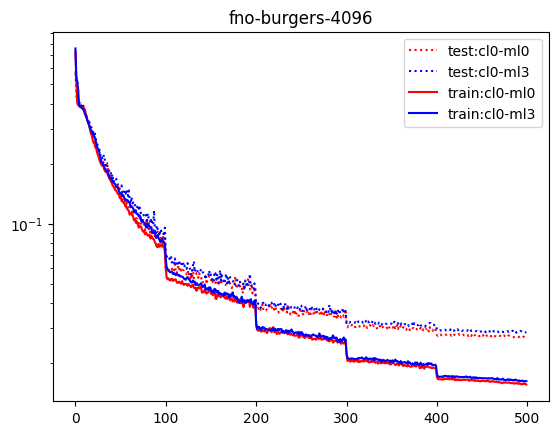

In [116]:
plt.plot(fno_burgers_cl0_ml0['test_mean'], color='red', linestyle='dotted', label='test:cl0-ml0')
plt.plot(fno_burgers_cl0_ml3['test_mean'], color='blue', linestyle='dotted', label='test:cl0-ml3')
plt.plot(fno_burgers_cl0_ml0['tra_mean'], color='red', linestyle='solid', label='train:cl0-ml0')
plt.plot(fno_burgers_cl0_ml3['tra_mean'], color='blue', linestyle='solid', label='train:cl0-ml3')
plt.title('fno-burgers-4096')
plt.yscale('log')
plt.legend()

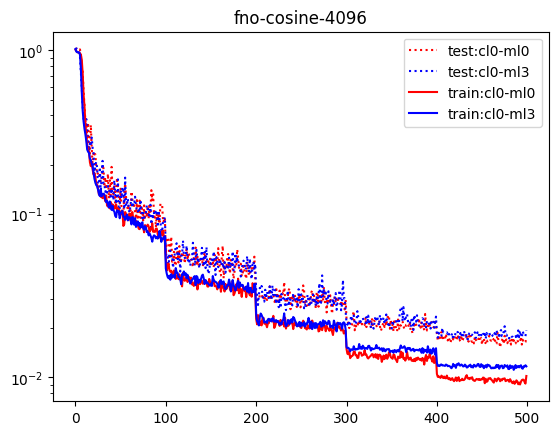

In [117]:
plt.plot(fno_cosine_cl0_ml0['test_mean'], color='red', linestyle='dotted', label='test:cl0-ml0')
plt.plot(fno_cosine_cl0_ml3['test_mean'], color='blue', linestyle='dotted', label='test:cl0-ml3')
plt.plot(fno_cosine_cl0_ml0['tra_mean'], color='red', linestyle='solid', label='train:cl0-ml0')
plt.plot(fno_cosine_cl0_ml3['tra_mean'], color='blue', linestyle='solid', label='train:cl0-ml3')
plt.title('fno-cosine-4096')
plt.yscale('log')
plt.legend()

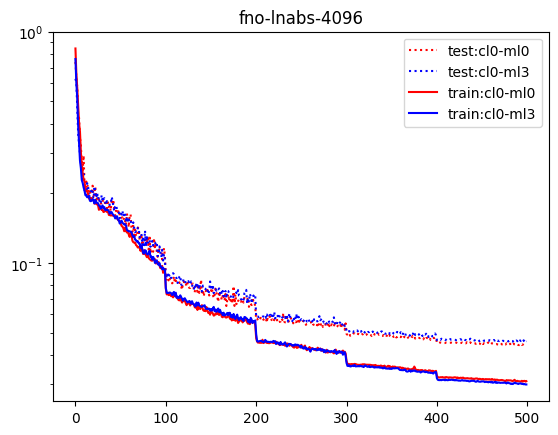

In [118]:
plt.plot(fno_lnabs_cl0_ml0['test_mean'], color='red', linestyle='dotted', label='test:cl0-ml0')
plt.plot(fno_lnabs_cl0_ml3['test_mean'], color='blue', linestyle='dotted', label='test:cl0-ml3')
plt.plot(fno_lnabs_cl0_ml0['tra_mean'], color='red', linestyle='solid', label='train:cl0-ml0')
plt.plot(fno_lnabs_cl0_ml3['tra_mean'], color='blue', linestyle='solid', label='train:cl0-ml3')
plt.title('fno-lnabs-4096')
plt.yscale('log')
plt.legend()